In [1]:
import eigsep_data as ed
import numpy as np
import matplotlib.pyplot as plt

# Field S11s at each cal plane
Below is shown all the DUTs being measured at each relevant calibration plane. The S11 class takes in the the directory with the files generated by the calibration script.

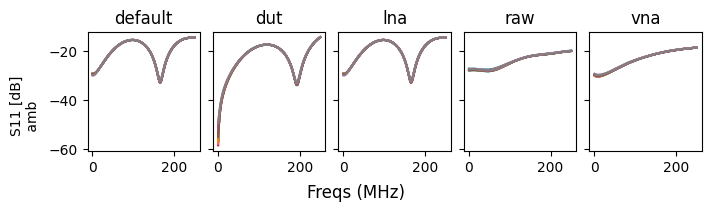

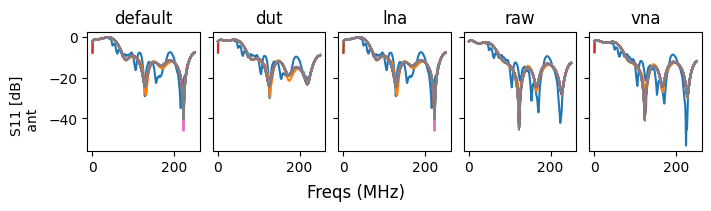

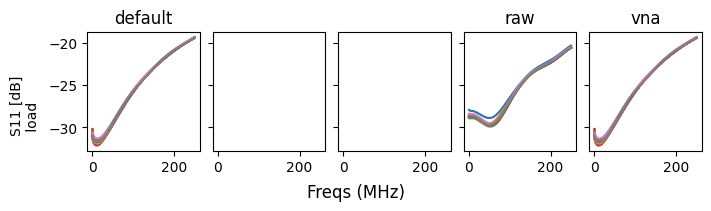

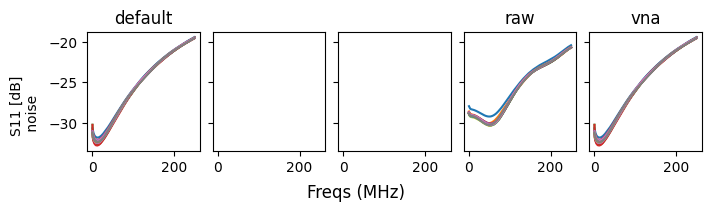

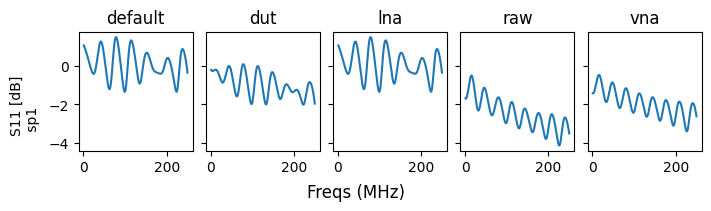

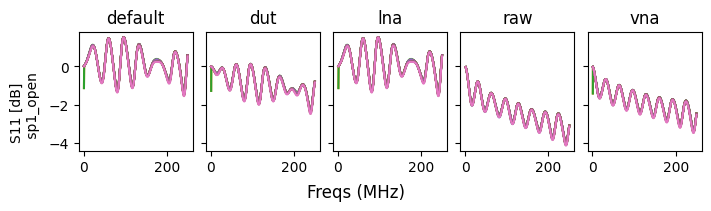

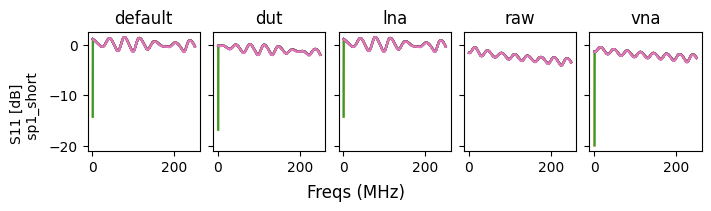

In [11]:
field_data = ed.s11.S11('testing_cal_script')
freqs = field_data.freqs
for dut in field_data.duts:
    if dut == 'rec':
        continue
    fig, axs = plt.subplots(figsize=(7,2), ncols=len(field_data.ant_planes), sharex=True, sharey=True, layout='constrained')
    fig.supxlabel('Freqs (MHz)')
    fig.supylabel(f'S11 [dB]\n {dut} ', fontsize=10, verticalalignment='center', horizontalalignment='left')
    for idx, plane in enumerate(field_data.ant_planes):
        try:
            s11 = field_data.get_all_s11s(dut=dut, plane=plane)[1]
            axs[idx].plot(freqs/1e6, 20*np.log10(np.abs(s11.T)))
            axs[idx].set_title(plane)
            
        except Exception as e:
            e
    plt.show()

# Getting one S11 closest to timestamp
S11.get_s11 takes in a dut ('rec', 'ant', 'amb', 'sp1_short', 'sp1_open', 'load', 'noise') and a timestamp, and returns an S11 at the default calibration plane (set when the calibration script runs). 

1784260950.5724194


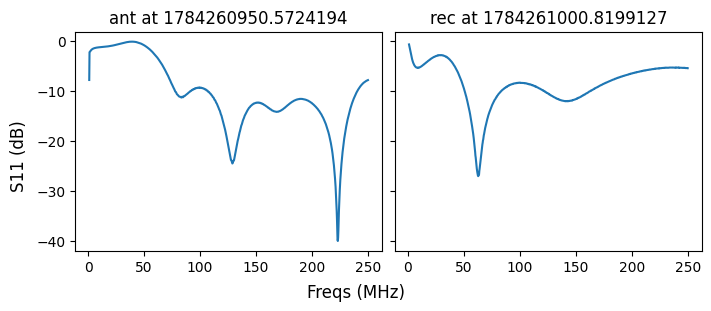

In [16]:
ts = list(field_data.ant.keys())[2] #example timestamp
print(ts)
ans11 = field_data.get_s11(dut='ant', timestamp=ts)
fig, axs = plt.subplots(figsize=(7,3), ncols=2, sharex=True, sharey=True, layout='constrained')
axs[0].plot(freqs/1e6, 20*np.log10(np.abs(ans11.dut_s11)))
axs[0].set_title(f"{ans11.dut} at {ans11.dut_time}")
axs[1].plot(freqs/1e6, 20*np.log10(np.abs(ans11.rec_s11)))
axs[1].set_title(f"rec at {ans11.rec_time}")
fig.supxlabel('Freqs (MHz)')
fig.supylabel('S11 (dB)')
plt.show()